# Zones

Here we illustrate how to define and work with zones, using the ``atomsmltr.environment.zones`` subpackage

## Introduction to zones

### Defining zone

The ``Zone`` class allows to define zones in the position-velocity space, that are associated with actions. Currently, the only action that is implemented is "stop", and it means that the simulation will stop when an atom steps **outside** of the defined zone.

When creating a zone, users should specify whether they apply to 'position' or 'speed' using the ``target`` property. Then, one can check whether a position or speed vector is inside the zone using the ``in_zone()`` method.

Note that regular zones are designed to deal with only position or speed vector, and hence the ``in_zone()`` takes a vector of shape (,3) or (n,m,..,3) as an input. To work with position-velocity vectors of dimension (...,6), there is a special type of zone collection : ``SuperZone``

In [21]:
# - "1D" zones > limits
from atomsmltr.environment import UpperLimit, LowerLimit, Limits 

# define a zone corresponding to x > 0
x_pos = LowerLimit(value=0, axis=0, target="position", action="stop", tag="positive x")
x_pos.print_info()
print(x_pos.get_value((1,0,0)))
print(x_pos.get_value((-1,0,0)))

───────────────
| Upper Limit |
───────────────
. Parameters :
  ├── type : 1D lower limit
  ├── tag : positive x
  ├── target : position
  ├── action : stop
  ├── value : 0.0
  ├── axis : 0
  └── inverted : False


True
False


In [23]:
# - other examples
# zone -10 < y < 10
y_limits = Limits(min=-10, max=10, axis=1, target="position", tag="y limits")
# zone vz < 500
vz_max = UpperLimit(value=500, axis=2, target="speed", tag="vz cap")

The logic of a zone can be inverted using the ``inverted`` property :

In [25]:
from atomsmltr.environment import UpperLimit

xlim = UpperLimit(10, axis=0, target="position")
print(xlim.get_value((20, 0, 0)))
xlim.inverted = True
print(xlim.get_value((20, 0, 0)))

False
True


### Examples of 3D zones

Currently two kind of 3D zones are implemented: **Box** and **Cylinder**

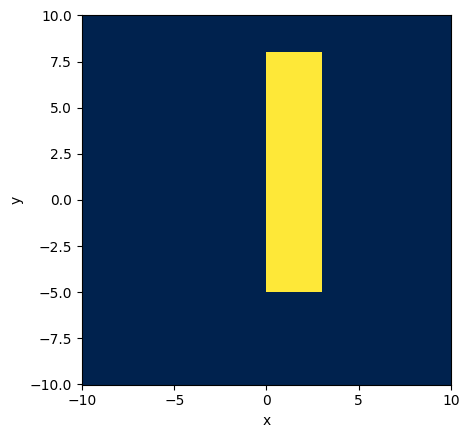

In [28]:
from atomsmltr.environment import Box
import numpy as np
import matplotlib.pyplot as plt

# -- setup zone
zone = Box(xmin=0, xmax=3, ymin=-5, ymax=8, zmin=-8, zmax=8, target="position")

# -- plot

# prepare the grid
grid = np.mgrid[-10:10:500j, -10:10:500j, 0:0:1j]
grid = np.squeeze(grid)
X, Y, _ = grid
X, Y = X.T, Y.T
pos = grid.T

# compute result
res = zone.get_value(pos)

# plot
plt.figure()
plt.pcolormesh(X, Y, res, cmap="cividis")
plt.gca().set_aspect('equal')
plt.xlabel("x")
plt.ylabel("y")
plt.show()

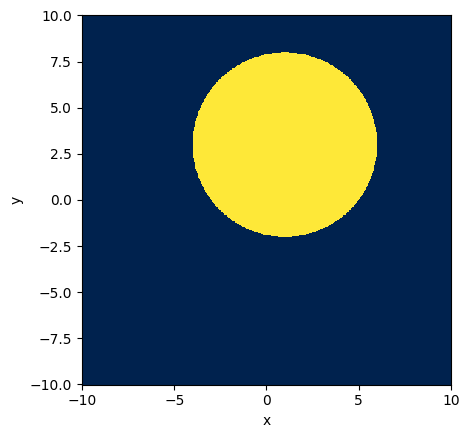

In [29]:
from atomsmltr.environment import Cylinder
import numpy as np
import matplotlib.pyplot as plt

# -- setup zone
zone = Cylinder(origin=(1,3,0), direction=(0,0,1), radius=5, target="position")

# -- plot

# prepare the grid
grid = np.mgrid[-10:10:500j, -10:10:500j, 0:0:1j]
grid = np.squeeze(grid)
X, Y, _ = grid
X, Y = X.T, Y.T
pos = grid.T

# compute result
res = zone.get_value(pos)

# plot
plt.figure()
plt.pcolormesh(X, Y, res, cmap="cividis")
plt.gca().set_aspect('equal')
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## Zone collections

### Create a collection

Simple zones can be combined using the logical operators ``&`` (and), ``|`` (or) , ``^`` (xor) to create zone collections. 

Hence, there are three kind of zone collections : ``ANDCollection``, ``ORCollection``, ``XORCollection``.

A zone collection contains a list of zones, and the result is evaluated by combining the result of each zone and "adding" them using the logical operator. It is possible to add zones to the list using the ``+=`` operator. Note that only zones collections of the same kind (or, and, xor) can be added using the ``+=`` operator ; in this case, the lists of zones are merged.

Finally, note that a ``ZoneCollection`` is still a ``Zone`` , so it is possible to combine them with other ``Zone`` objects to create new collections.

───────────────────────
| AND Zone Collection |
───────────────────────
. Parameters :
  ├── type : AND Zone Collection
  ├── tag : vivusu
  ├── target : position
  ├── action : stop
  ├── zones : ['x limits', 'y limits']
  └── inverted : False




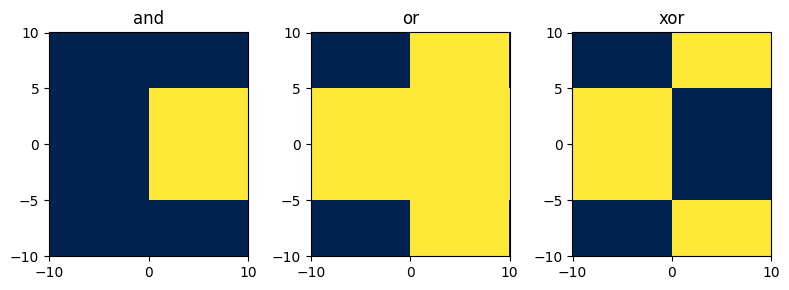

In [40]:
from atomsmltr.environment import Limits
import numpy as np
import matplotlib.pyplot as plt

# -- define y and y limits
xlim = Limits(0, 10, axis=0, tag="x limits")
ylim = Limits(-5, 5, axis=1, tag="y limits")

# -- try collections
and_coll = xlim & ylim 
or_coll = xlim | ylim
xor_coll = xlim ^ ylim

and_coll.print_info()

# -- plot

# prepare the grid
grid = np.mgrid[-10:10:500j, -10:10:500j, 0:0:1j]
grid = np.squeeze(grid)
X, Y, _ = grid
X, Y = X.T, Y.T
pos = grid.T

# compute result
res_and = and_coll.get_value(pos)
res_or = or_coll.get_value(pos)
res_xor = xor_coll.get_value(pos)

# plot
fig, axes = plt.subplots(1,3,figsize=(8,3), tight_layout=True)
axes[0].pcolormesh(X, Y, res_and, cmap="cividis")
axes[0].set_title("and")
axes[1].pcolormesh(X, Y, res_or, cmap="cividis")
axes[1].set_title("or")
axes[2].pcolormesh(X, Y, res_xor, cmap="cividis")
axes[2].set_title("xor")
plt.show()

### Operations on collection

In [48]:
from atomsmltr.environment import UpperLimit, LowerLimit

# -- define limits
x_min = LowerLimit(0, axis=0, tag="x_min")
y_min = LowerLimit(-1, axis=1, tag="y_min")
z_min = LowerLimit(-10, axis=2, tag="z_min")
x_max = UpperLimit(0, axis=0, tag="x_max")
y_max = UpperLimit(-1, axis=1, tag="y_max")
z_max = UpperLimit(-10, axis=2, tag="z_max")


# -- play with collections
# combine x_min and x_max
xlim = x_max & x_min
xlim.tag = "xlim"
# now xlim is a collection of two zones
print([z.tag for z in xlim.zones])    
# same with y
ylim = y_max & y_min
ylim.tag = "ylim"
print([z.tag for z in ylim.zones])

# How to combine them ?
# option 1 : "merge"
xylim = xlim + ylim  # addition works since both are ANDCollections
print([z.tag for z in xylim.zones])

# option 2 : combine them in a new collection
xylim = xlim & ylim
print([z.tag for z in xylim.zones])  # then the new collection has only two zones

# increment also works
all_lim = ylim + xlim
all_lim += z_min
all_lim += z_max
print([z.tag for z in all_lim.zones])  # then the new collection has only two zones

['x_max', 'x_min']
['y_max', 'y_min']
['x_max', 'x_min', 'y_max', 'y_min']
['xlim', 'ylim']
['y_max', 'y_min', 'x_max', 'x_min', 'z_min', 'z_max']


## A few examples of zones collections

### using OR collection

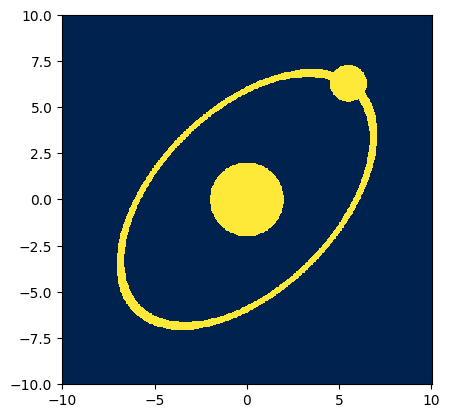

In [35]:
from atomsmltr.environment.zones import Cylinder
import numpy as np
import matplotlib.pyplot as plt

# -- generate the zone

# create two cylinders
cyl_1 = Cylinder()
cyl_1.origin = (0, 0, 0)
cyl_1.direction = (1, 1, 1)
cyl_1.radius = 5

# the second one is inverted
cyl_2 = cyl_1.copy()
cyl_2.radius = 4.7
cyl_2.inverted = True

# the union of the tw0
orbit = cyl_1 & cyl_2

# add another cylinder
nucleus = Cylinder()
nucleus.origin = (0, 0, 0)
nucleus.direction = (0, 0, 1)
nucleus.radius = 2

# and a last one
electron = Cylinder()
electron.origin = (5.5, 6.3, 0)
electron.direction = (0, 0, 1)
electron.radius = 1

# combine them in a "OR" collection
coll = orbit | nucleus | electron

# -- plot

# prepare the grid
grid = np.mgrid[-10:10:500j, -10:10:500j, 0:0:1j]
grid = np.squeeze(grid)
X, Y, _ = grid
X, Y = X.T, Y.T
pos = grid.T

# compute result
res = coll.get_value(pos)

# plot
plt.figure()
plt.pcolormesh(X, Y, res, cmap="cividis")
plt.gca().set_aspect('equal')
plt.show()

### playing with XOR

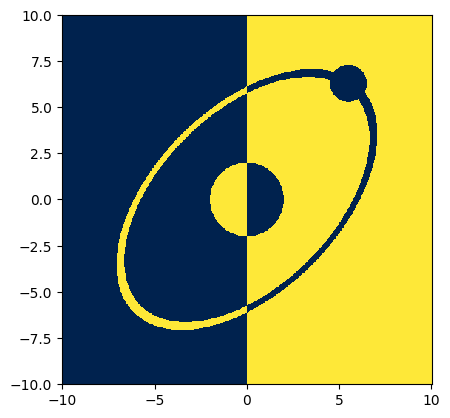

In [14]:
# - One step further
from atomsmltr.environment import LowerLimit
x_positive = LowerLimit(value=0, axis=0)
coll_2 = coll ^ x_positive  # xor

# compute result
res = coll_2.get_value(pos)

# plot
plt.figure()
plt.pcolormesh(X, Y, res, cmap="cividis")
plt.gca().set_aspect('equal')
plt.show()

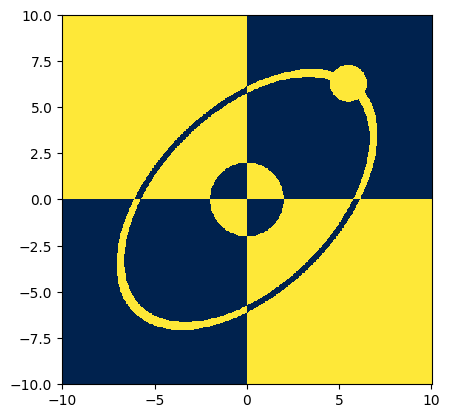

In [18]:
# - Go on with that ?
y_positive = LowerLimit(value=0, axis=1)
coll_3 = coll_2 ^ y_positive

# compute result
res = coll_3.get_value(pos)

# plot
plt.figure()
plt.pcolormesh(X, Y, res, cmap="cividis")
plt.gca().set_aspect('equal')
plt.show()